In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)
import yfinance as yf
from datetime import datetime
print("Everything works!")


tickers = ["TSLA", "SPY", "BND"]

start_date = "2015-01-01"
end_date = "2026-06-30"

#Download 

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True
    )

    df["Ticker"] = ticker
    data[ticker] = df

# SAFE CONCAT (forces clean vertical stacking)
combined = pd.concat(
    [data[t] for t in tickers],
    axis=0
)

combined = combined.reset_index()

# Save correctly
combined.to_csv("data/processed/stock_data.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 8665 entries, 0 to 8664
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      8664 non-null   str  
 1   Close     2889 non-null   str  
 2   High      2889 non-null   str  
 3   Low       2889 non-null   str  
 4   Open      2889 non-null   str  
 5   Volume    2889 non-null   str  
 6   Ticker    8664 non-null   str  
 7   Close.1   2889 non-null   str  
 8   High.1    2889 non-null   str  
 9   Low.1     2889 non-null   str  
 10  Open.1    2889 non-null   str  
 11  Volume.1  2889 non-null   str  
 12  Close.2   2889 non-null   str  
 13  High.2    2889 non-null   str  
 14  Low.2     2889 non-null   str  
 15  Open.2    2889 non-null   str  
 16  Volume.2  2889 non-null   str  
dtypes: str(17)
memory usage: 1.1 MB


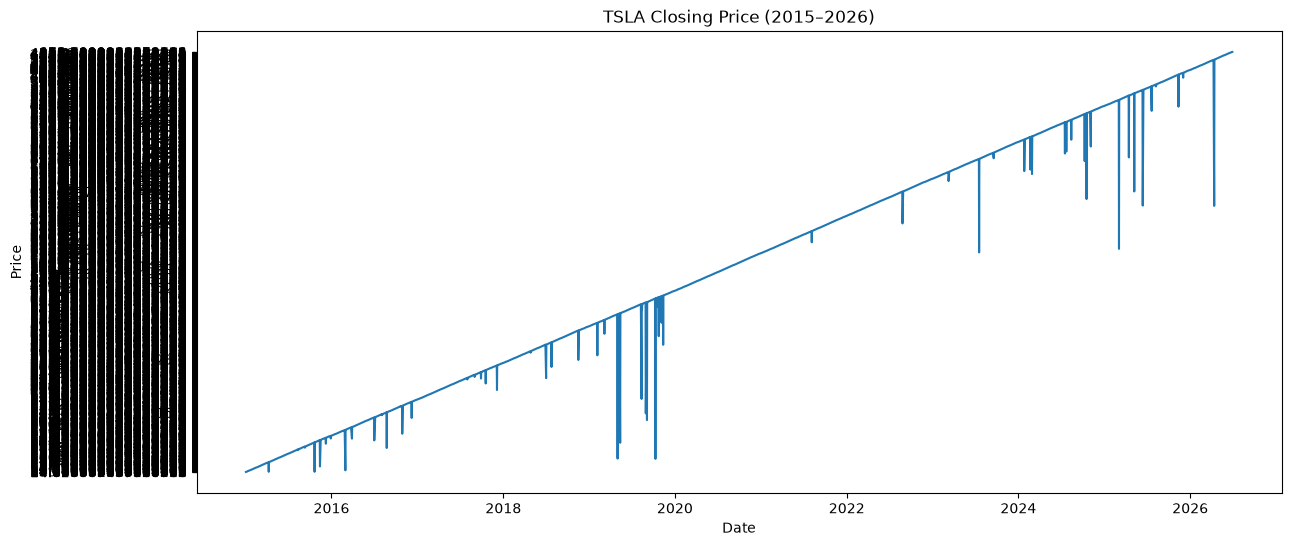

In [17]:
df = pd.read_csv("../data/processed/stock_data.csv")

df.head()
df.info()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.isnull().sum()
df = df.ffill()
df.describe()

#stock price over time 

import matplotlib.pyplot as plt

tsla = df[df["Ticker"] == "TSLA"]

plt.figure(figsize=(14,6))
plt.plot(tsla["Date"], tsla["Close"])
plt.title("TSLA Closing Price (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [19]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Close.1',
       'High.1', 'Low.1', 'Open.1', 'Volume.1', 'Close.2', 'High.2', 'Low.2',
       'Open.2', 'Volume.2'],
      dtype='str')


In [20]:
#Daily Returns + Volatility Analysis
df["Daily Return"] = df.groupby("Ticker")["Close"].pct_change()
df.head()

#veleocity comparision
plt.figure(figsize=(14,6))

for ticker in ["TSLA", "SPY", "BND"]:
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Daily Return"], label=ticker, alpha=0.6)

plt.title("Daily Returns Comparison")
plt.legend()
plt.show()

#rolling velocity
df["Rolling Volatility"] = (
    df.groupby("Ticker")["Daily Return"]
    .transform(lambda x: x.rolling(30).std())
)

tsla = df[df["Ticker"] == "TSLA"]

plt.figure(figsize=(14,6))
plt.plot(tsla["Date"], tsla["Rolling Volatility"])
plt.title("TSLA 30-Day Rolling Volatility")
plt.show()



TypeError: unsupported operand type(s) for /: 'str' and 'str'